<a href="https://colab.research.google.com/github/Rankskun/Neural-Collaborative-Filtering-NCF-for-Movie-Rating-Predictio/blob/main/Student_Academic_Performance_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analisis Performa Akademik Siswa**

### Kelompok 8
Anggota Kelompok :
1. Sahrul Romadi - 41521010084
2. Rangga Putra Mardiansyah - 41521010073
3. Adik Firman Maulana A - 41521010105

## **Pendahuluan**

### **Latar Belakang**
Menganalisis performa seorang siswa adalah bagian penting dari mengajar. Seorang Guru memberikan tugas dan memeriksa tugas siswa sepanjang waktu untuk menilai performa belajar siswa, memperbaiki dan meningkatkan sistem mengajar. Penilaian performa siswa secara berkelanjutan memungkinkan guru untuk terlibat dalam peningkatan kualitas mengajar mereka secara berkelanjutan. Banyak faktor yang dapat mempengaruhi prestasi siswa, antara lain jenis kelamin, pengaruh latar belakang pendidikan orang tua, makanan, persiapan ujian, dan lain sebagainya.

### **Rumusan Masalah**
Bagaimana pengaruh jenis kelamin, latar belakang pendidikan orang tua, makanan, persiapan ujian terhadap performa siswa?

### **Tujuan**
Dapat mengetahui pengaruh jenis kelamin, latar belakang orang tua, makanan, persiapan ujian terhadap performa siswa.

## **Pembahasan**

### **Library**
1. pandas -> Untuk manipulasi dan analisis data
2. missingno -> Untuk memvisualisasikan dan mengidentifikasi data yang hilang (missing) dalam dataset.
3. numpy -> Untuk komputasi numerik, termasuk operasi matematika, array multidimensi, dan aljabar linear.
4. matplotlib.pyplot -> Untuk membuat grafik dan visualisasi data.
5. seaborn -> Untuk membuat visualisasi data statistik yang indah dan informatif.

### **Ilmu Matermatika yang digunakan**
1. Mean -> Rata-rata
2. Modus -> Nilai yang sering muncul

### **Alur Pengerjaan**
1. Menghitung rata-rata dari 3 data nilai
2. Bandingkan dan visualisasikan rata-rata nilai dengan masing-masing faktor yaitu jenis kelamin, pengaruh latar belakang orang tua, makanan, dan persiapan ujian
3. Buat Kesimpulan



## **Coding**

In [ ]:
# Import library
import pandas as pd
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Masukkan dataset
df=pd.read_csv("StudentsPerformance.csv")

### **Dataset**

In [ ]:
df.shape

(1000, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

### **Cleaning**

**Pengecekan Data**

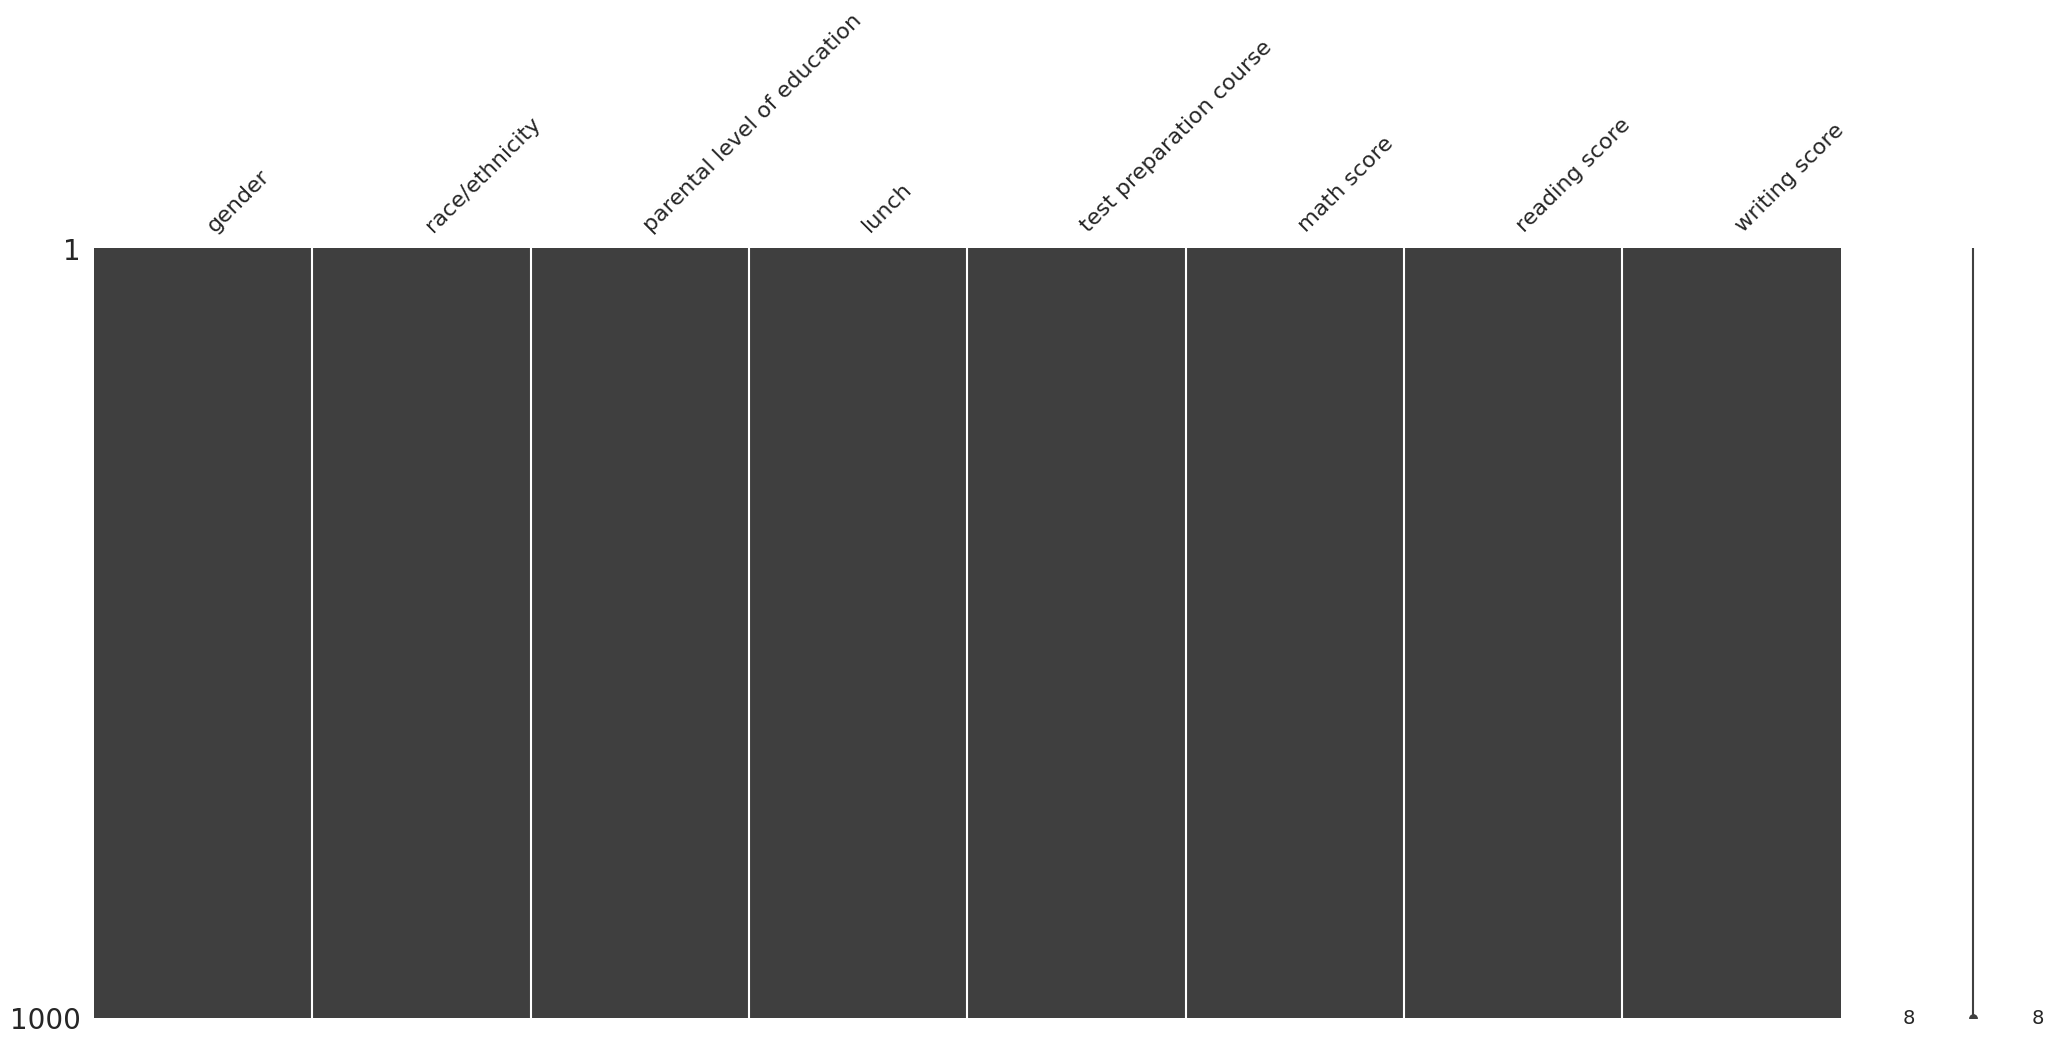

In [ ]:
# Melihat apakah ada data yang hilang
msno.matrix(df);

Tidak ada pola aneh yang ditemukan

In [ ]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Tidak ada missing values = data bersih

**Membuat Data menjadi Kotor**

In [ ]:
# Identifikasi baris yang ingin Anda duplikasi
rows_to_duplicate = [0, 2]  # Indeks baris yang ingin digandakan

# Duplikasi baris-baris yang dipilih
duplicated_rows = df.iloc[rows_to_duplicate].copy()
df = pd.concat([df, duplicated_rows], ignore_index=True)

In [ ]:
df.shape

# Terlihat adanya penambahan atribut

(1002, 8)

In [ ]:
print (df)

# Terlihat ada data yang duplikat

      gender race/ethnicity parental level of education         lunch  \
0     female        group B           bachelor's degree      standard   
1     female        group C                some college      standard   
2     female        group B             master's degree      standard   
3       male        group A          associate's degree  free/reduced   
4       male        group C                some college      standard   
...      ...            ...                         ...           ...   
997   female        group C                 high school  free/reduced   
998   female        group D                some college      standard   
999   female        group D                some college  free/reduced   
1000  female        group B           bachelor's degree      standard   
1001  female        group B             master's degree      standard   

     test preparation course  math score  reading score  writing score  
0                       none          72          

**Cleaning**

In [ ]:
# Menghapus data yang duplikat
df = df.drop_duplicates()

df.shape
# Terlihat atribut data kembali menjadi seperti awal yaitu 1000

(1000, 8)

In [ ]:
# Tampilan setelah dibersihkan
print (df)

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

### **Persiapan data**

In [ ]:
# Karena total nilainya untuk setiap mata pelajaran ada 100, passmark nya 35
passmark=35

In [ ]:
# Buat 3 kolom baru yaitu Total_Marks, Percentage dan Grade
# Percentage
df['Percentage'] = (df['math score']+df['reading score']+df['writing score'])/3

In [ ]:
def Grade(Percentage):
    if (Percentage >= 95):return 'O'
    if (Percentage >= 81):return 'A'
    if (Percentage >= 71):return 'B'
    if (Percentage >= 61):return 'C'
    if (Percentage >= 51):return 'D'
    if (Percentage >= 41):return 'E'
    else: return 'F'

# Grade
df["grade"] = df.apply(lambda x : Grade(x["Percentage"]), axis=1)

In [ ]:
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Percentage,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,B
1,female,group C,some college,standard,completed,69,90,88,82.333333,A
2,female,group B,master's degree,standard,none,90,95,93,92.666667,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,E
4,male,group C,some college,standard,none,76,78,75,76.333333,B
5,female,group B,associate's degree,standard,none,71,83,78,77.333333,B
6,female,group B,some college,standard,completed,88,95,92,91.666667,A
7,male,group B,some college,free/reduced,none,40,43,39,40.666667,F
8,male,group D,high school,free/reduced,completed,64,64,67,65.000000,C
9,female,group B,high school,free/reduced,none,38,60,50,49.333333,E


In [ ]:
df.describe()

,math score,reading score,writing score,Percentage
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


### **Visualisasi**

Persentase jenis kelamin dari jumlah siswa di dataset

In [ ]:
sns.set(style='whitegrid')

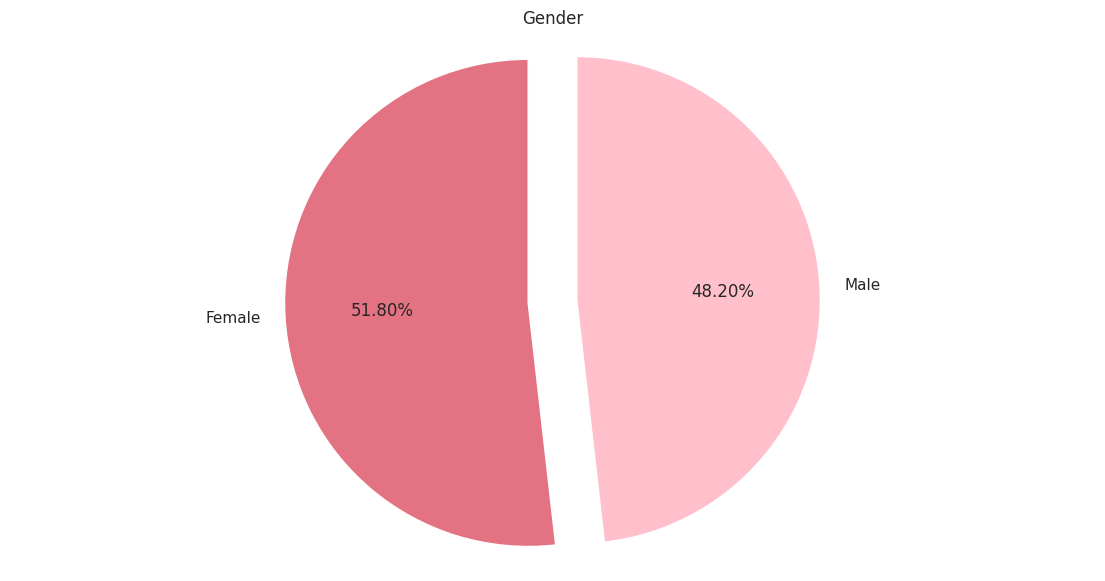

In [ ]:
plt.figure(figsize=(14, 7))
labels=['Female', 'Male']
plt.pie(df['gender'].value_counts(),labels=labels,explode=[0.1,0.1],
        autopct='%1.2f%%',colors=['#E37383','#FFC0CB'], startangle=90)
plt.title('Gender')
plt.axis('equal')
plt.show()

Dari jumlah siswa di dataset, terdapat 48.20% male dan 51.80% female

### **Faktor Jenis kelamin**

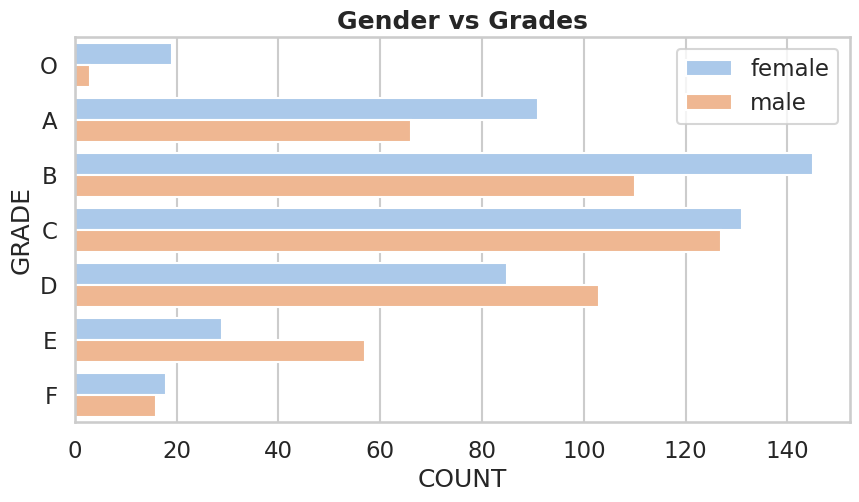

In [ ]:
plt.figure(figsize=(10,5))
sns.set_context("talk",font_scale=1)
sns.set_palette("pastel")
ax = sns.countplot(y="grade", hue="gender", data=df, order=["O","A","B","C","D","E","F"])
ax.legend(loc='upper right',frameon=True)
plt.title('Gender vs Grades', fontsize=18, fontweight='bold')
ax.set(xlabel='COUNT',ylabel='GRADE')
plt.show()

Distribusi grade berdasarkan jenis kelamin

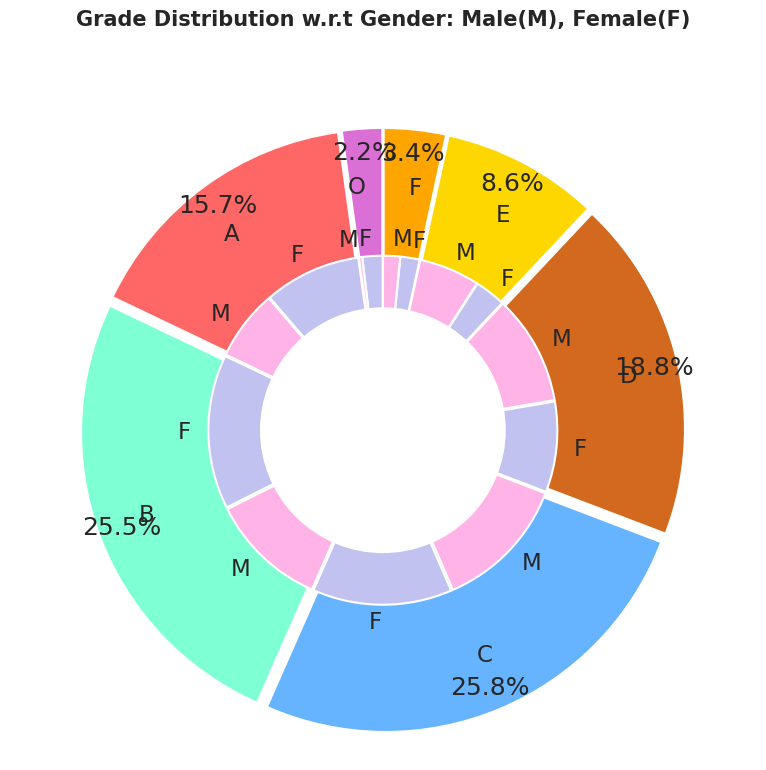

In [ ]:
plt.figure(figsize=(8, 8))
labels =["O","A","B","C","D","E","F"]
values = [22,157,255,258,188,86,34]
labels_gender = ["F","M","F","M","F","M","F","M","F","M","F","M","F","M"]
sizes_gender = [19,3,91,66,145,110,131,127,85,103,29,57,18,16]
colors = ['orchid', '#ff6666', 'aquamarine', '#66b3ff','chocolate','gold','orange']
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6']
explode = (0.3,0.3,0.3,0.3,0.3,0.3,0.3)
explode_gender = (0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1)
#Plot
plt.pie(values, labels=labels,autopct='%1.1f%%' ,pctdistance=0.92, labeldistance=0.80,colors=colors, startangle=90,frame=True, explode=explode,radius=12)
plt.pie(sizes_gender,labels=labels_gender,colors=colors_gender,startangle=90, explode=explode_gender,radius=7)
#Draw circle
centre_circle = plt.Circle((0,0),5,color='black', fc='white',linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Grade Distribution w.r.t Gender: Male(M), Female(F)', fontsize=15, fontweight='bold',y=1.1)

# show plot

plt.axis('equal')
plt.tight_layout()
plt.show()

Dari visualisasi diatas, dapat disimpulkan bahwa:
1. Mayoritas siswa yang mendapat nilai O adalah perempuan
2. Mayoritas siswa yang mendapat nilai  B hampir sama dengan mendapat nilai C
3. Siswa perempuan lebih banyak yang mendapat nilai A dan B dibandingkan siswa laki-laki
4. Lebih banyak siswa laki-laki yang mendapat nilai D dan E
5. Jumlah keduanya hampir sama, baik laki-laki maupun perempuan, yang mendapat nilai F

**Analis korelasi di setiap masing-masing mata pelajaran**

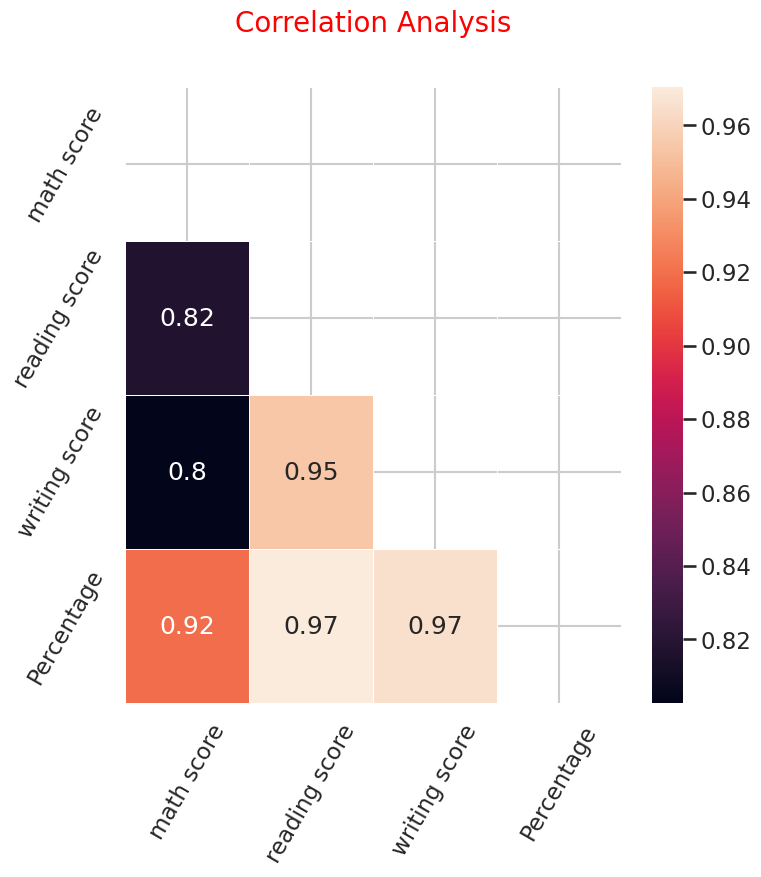

In [ ]:
plt.figure(figsize=(8,8))
plt.title('Correlation Analysis',color='Red',fontsize=20,pad=40)

corr = df.corr()
mask = np.triu(np.ones_like(corr,dtype = bool))
sns.heatmap(df.corr(),mask=mask,annot=True,linewidths=.5);
plt.xticks(rotation=60)
plt.yticks(rotation = 60)
plt.show()

Hampir semua nilainya berdekatan satu sama lain

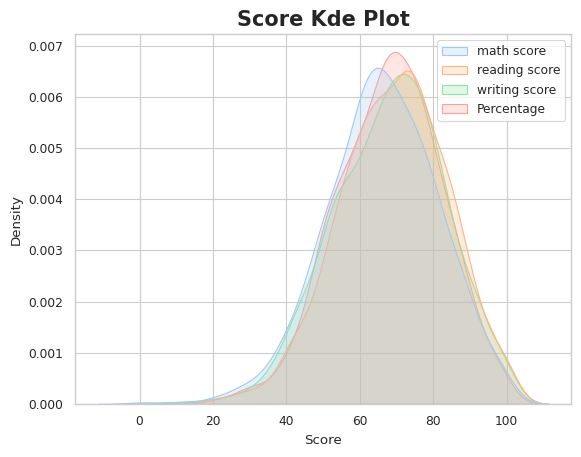

In [ ]:
sns.set_context("paper",font_scale=1)
sns.kdeplot(data=df,shade = True)
plt.xlabel('Score')
plt.title('Score Kde Plot', fontsize=15, fontweight='bold')
plt.show()

**Korelasi antar nilai dengan faktor gender**



**1. Membaca dan Matematika**

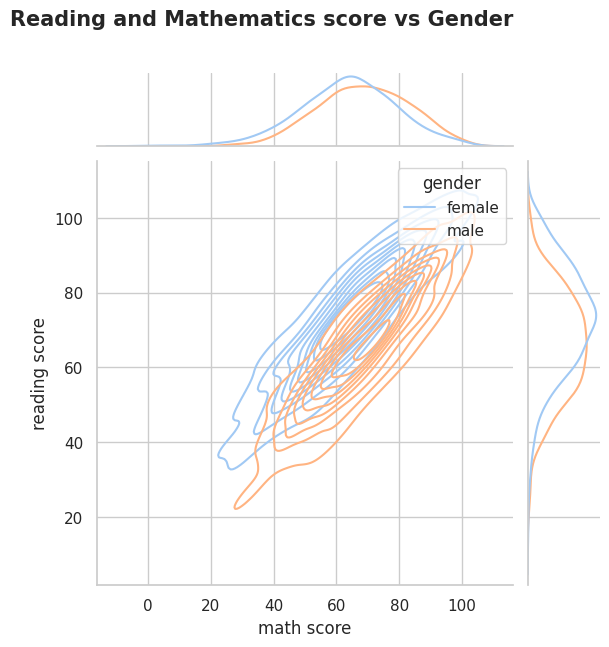

In [ ]:
sns.set_context("notebook")
sns.jointplot(data=df, x="math score", y="reading score", hue="gender", kind="kde")
plt.title('Reading and Mathematics score vs Gender', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

**2. Matematika dan menulis**

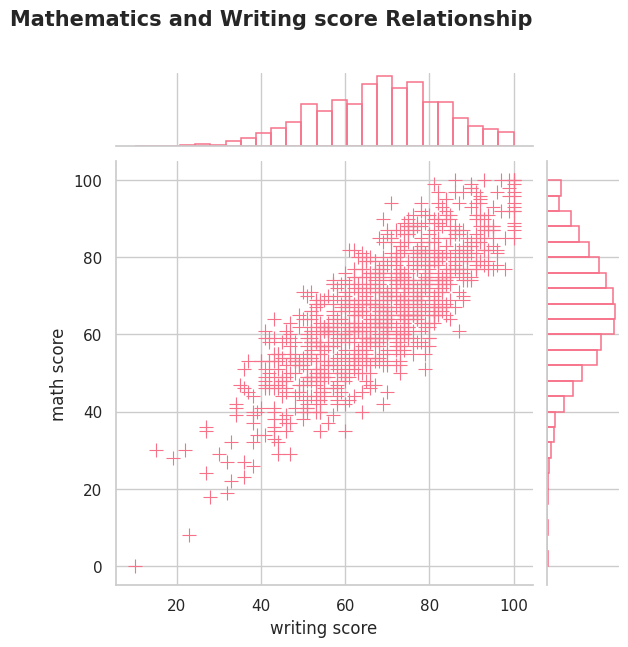

In [ ]:
sns.set_palette("husl", 9)
sns.jointplot(
    data=df, x="writing score", y="math score",
    marker="+", s=100, marginal_kws=dict(bins=25, fill=False),
)
plt.title('Mathematics and Writing score Relationship', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

Sebagian besar siswa berada di antara kisaran nilai 40 hingga 85 di mata pelajaran matematika, dan menulis

**3. Membaca dan menulis**

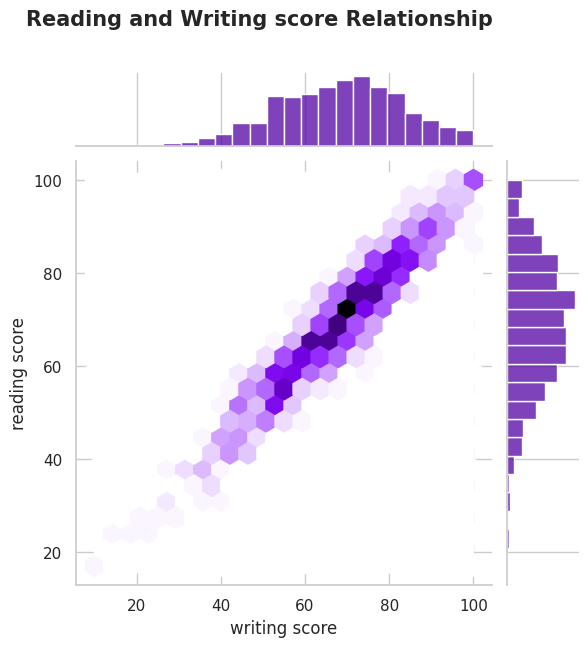

In [ ]:
sns.set_palette("plasma")
sns.jointplot(data=df, x="writing score", y="reading score", kind="hex")
plt.title('Reading and Writing score Relationship', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

Nilai rata-rata pada kedua mata pelajaran membaca dan menulis adalah sekitar 70

**Analisis masing-masing mata pelajaran**

**1. Matematika**

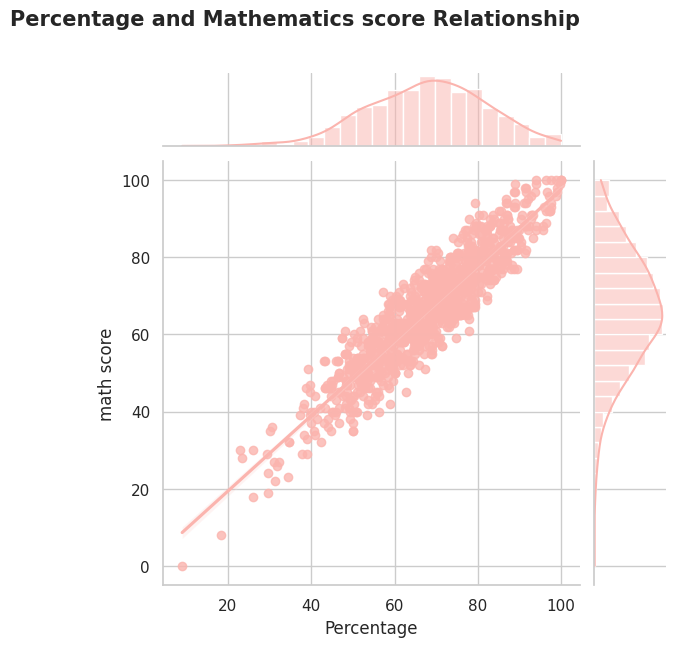

In [ ]:
sns.set_palette("Pastel1")
sns.jointplot(data=df, x="Percentage", y="math score", kind="reg")
plt.title('Percentage and Mathematics score Relationship', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

Kita dapat menemukan bahwa dalam hubungan antara persentase dan nilai matematika sebagian besar siswa mendapat nilai dalam kisaran 50 hingga 80

**2. Menulis**

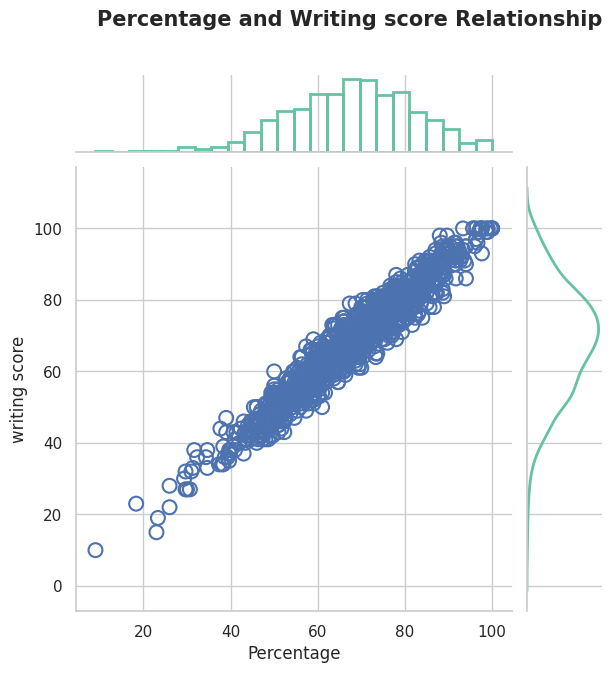

In [ ]:
sns.set_palette("Set2")
g = sns.JointGrid()
x, y = df["Percentage"], df["writing score"]
sns.scatterplot(x=x, y=y, ec="b", fc="none", s=100, linewidth=1.5, ax=g.ax_joint)
sns.histplot(x=x, fill=False, linewidth=2, ax=g.ax_marg_x)
sns.kdeplot(y=y, linewidth=2, ax=g.ax_marg_y)
plt.title('Percentage and Writing score Relationship', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

**3. Membaca**

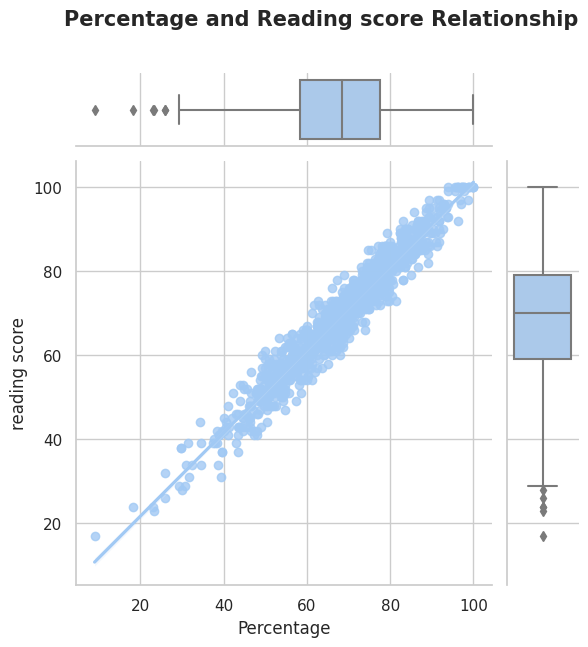

In [ ]:
sns.set_context("notebook")
sns.set_palette("pastel")
g = sns.JointGrid(data=df, x="Percentage", y="reading score")
g.plot(sns.regplot, sns.boxplot)
plt.title('Percentage and Reading score Relationship', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

Kita dapat menyimpulkan bahwa sebagian besar siswa mempunyai nilai membaca yang baik

### **Faktor Persiapan Ujian**

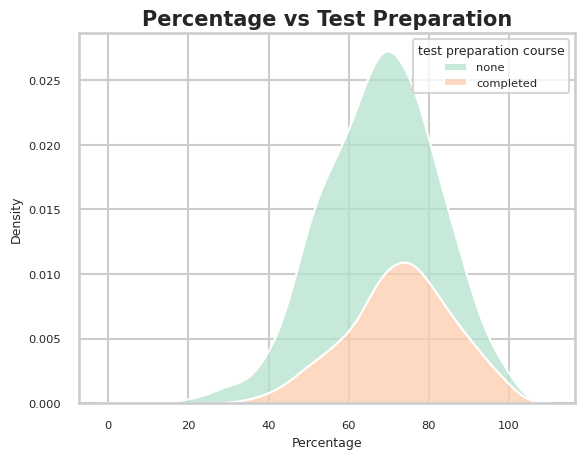

In [ ]:
sns.set_context("talk",font_scale=0.5)
sns.set_palette("Pastel2")
sns.kdeplot(data=df, x="Percentage", hue="test preparation course", multiple="stack")
plt.title('Percentage vs Test Preparation',fontsize=15, fontweight='bold')

plt.show()

**Matematika**

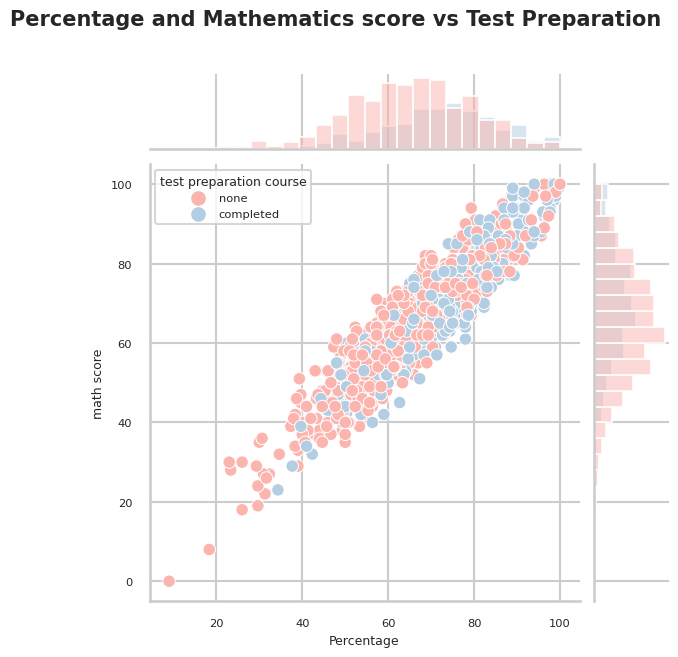

In [ ]:
sns.set_palette("Pastel1")
g = sns.JointGrid(data=df, x="Percentage", y="math score", hue="test preparation course")
g.plot(sns.scatterplot, sns.histplot)
plt.title('Percentage and Mathematics score vs Test Preparation ', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

Dari visualisasi di atas kita dapat menyimpulkan bahwa:

1. Siswa yang telah menyelesaikan persiapan ujiannya pasti mendapat nilai lebih baik. Sementara beberapa siswa yang tidak menyelesaikan persiapan ujiannya belum menunjukkan hasil yang baik
2. Kita dapat melihat bahwa hanya sedikit siswa yang mendapat nilai sangat baik dibandingkan dengan orang lain bahkan ketika mereka tidak menyelesaikan tes mereka
3. Selain itu, sangat sedikit yang menyelesaikan persiapan ujiannya tetapi persentase nilainya rendah

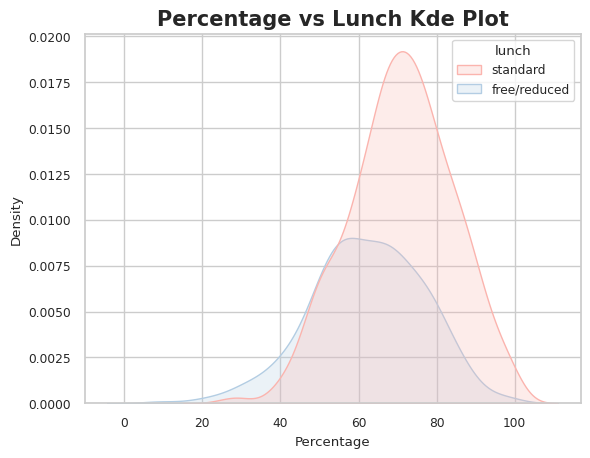

In [ ]:
sns.set_context("notebook",font_scale=0.8)
sns.kdeplot(data=df, x="Percentage", hue="lunch", multiple="layer",fill=True)
plt.xlabel('Percentage')
plt.title('Percentage vs Lunch Kde Plot',fontsize=15, fontweight='bold')

plt.show()

### **Faktor Makanan**

**Menulis**

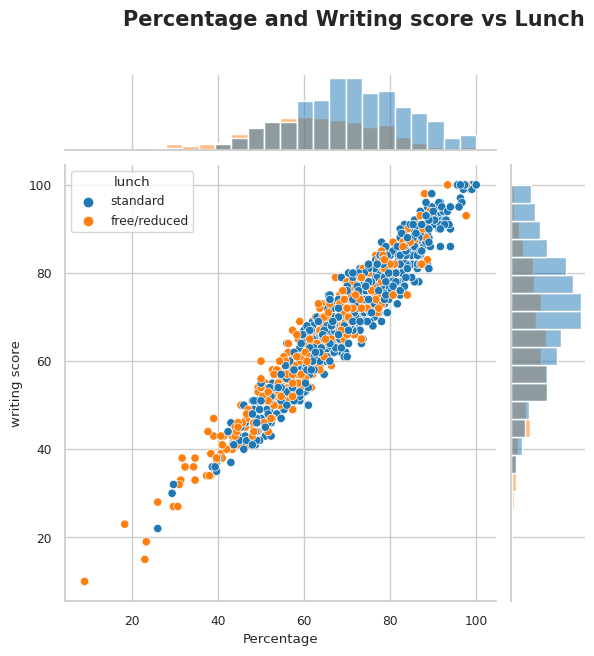

In [ ]:
sns.set_palette("tab10")
g = sns.JointGrid(data=df, x="Percentage", y="writing score", hue="lunch")
g.plot(sns.scatterplot, sns.histplot)
plt.title('Percentage and Writing score vs Lunch', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

Perhatikan rentang 75 hingga 100 pada visualisasi di atas.

- Siswa yang mendapatkan makan siang standar memiliki kinerja yang sangat baik
- Siswa yang mendapat makan siang gratis/dikurangi belum berprestasi dengan baik

Terlihat jelas bahwa makanan dan gizi memegang peranan penting dalam tumbuh kembang seorang siswa baik secara fisik maupun akademis. Nutrisi memainkan peran penting dalam perkembangan kesehatan anak-anak. Makanan bergizi memberi tubuh dan pikiran energi yang dibutuhkan untuk tumbuh, merasa sehat, aktif, tetap sehat, dan belajar. Siswa dapat belajar lebih baik jika mereka mendapat gizi yang baik, dan mengonsumsi makanan sehat dikaitkan dengan nilai yang lebih tinggi, daya ingat dan kewaspadaan yang lebih baik, serta pemrosesan informasi yang lebih cepat.

### **Faktor Latar Belakang Pendidikan Orang Tua**

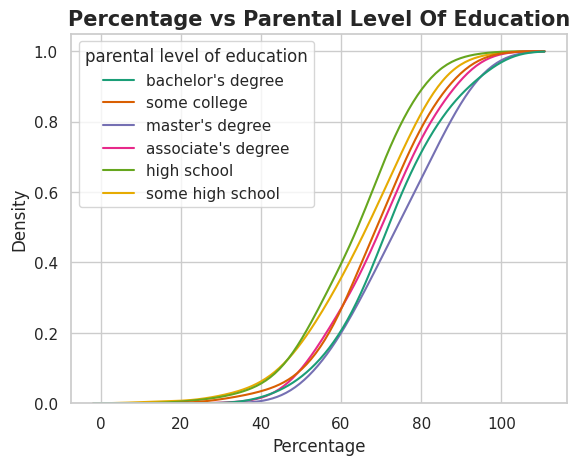

In [ ]:
sns.set_palette("Dark2")
sns.set_context("notebook",font_scale=1)
sns.kdeplot(
    data=df, x="Percentage", hue="parental level of education",
    cumulative=True, common_norm=False, common_grid=True,
)
plt.title('Percentage vs Parental Level Of Education',fontsize=15, fontweight='bold')

plt.show()

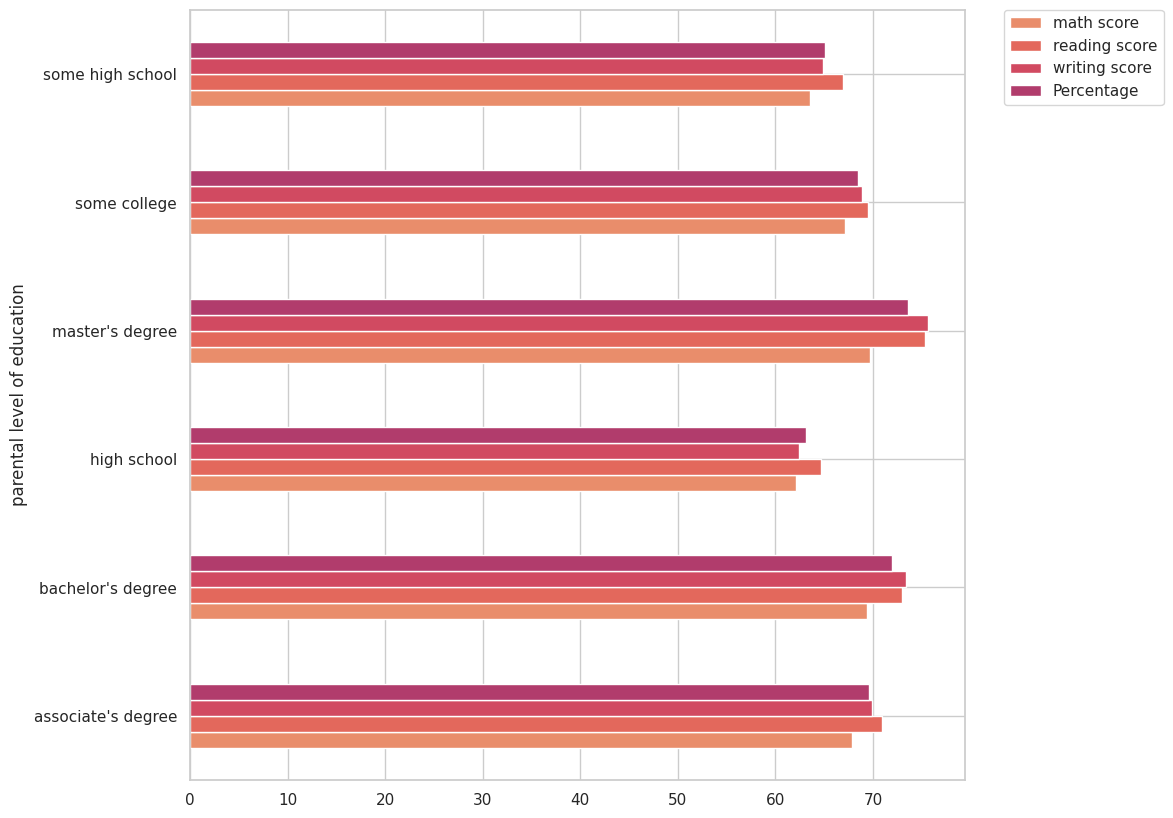

In [ ]:
sns.set_palette("flare")
df.groupby('parental level of education').agg('mean').plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.);

Siswa yang orang tuanya bergelar master memiliki persentase keseluruhan yang lebih tinggi.

**Berdasarkan Jenis Kelamin**

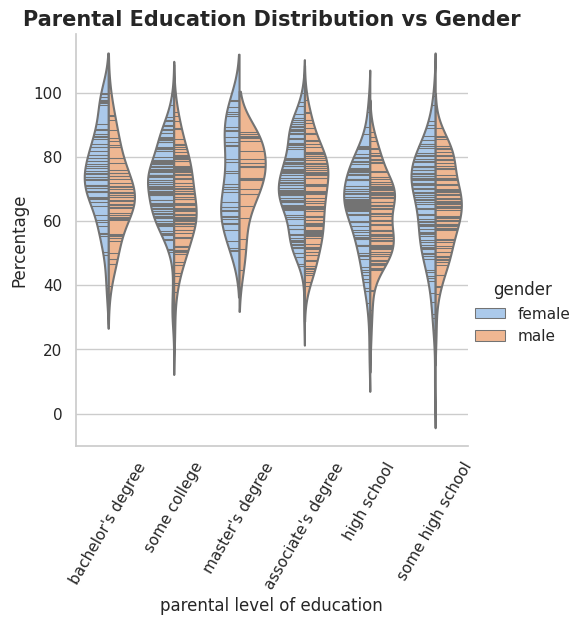

In [ ]:
sns.catplot(x="parental level of education", y="Percentage", hue="gender",
            kind="violin", inner="stick", split=True,
            palette="pastel", data=df)
plt.title('Parental Education Distribution vs Gender',fontsize=15, fontweight='bold')
plt.xticks(rotation=60)
plt.show()

- Perempuan yang orang tuanya bergelar Sarjana, diikuti dengan gelar master, memiliki presentasi lebih tinggi
- Laki-laki yang orang tuanya bergelar Sarjana dan Magister memiliki prestasi akademis yang serupa

### **Persentase Rata-Rata NIlai**

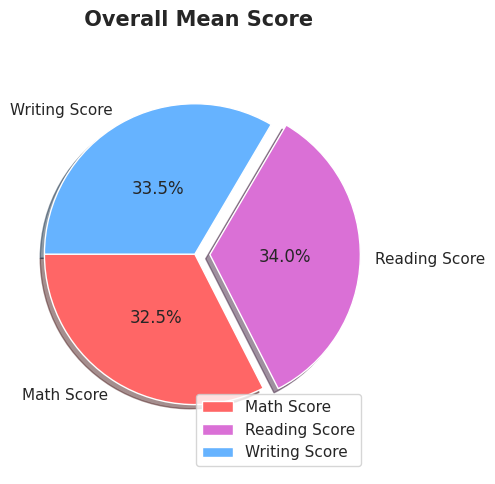

In [ ]:
plt.figure(figsize=(5,5))
labels=['Math Score', 'Reading Score', 'Writing Score']
colors=['#ff6666','orchid','#66b3ff']
explode=[0,0.1,0]
values=[df["math score"].mean(),df["reading score"].mean(),df["writing score"].mean()]

plt.pie(values,labels=labels,colors=colors,explode=explode,autopct='%1.1f%%',shadow=True,startangle=180,pctdistance=0.5)
plt.legend(['Math Score', 'Reading Score', 'Writing Score'],loc='lower right')
plt.axis('equal')
plt.title(' Overall Mean Score  ',fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Membaca memiliki rata-rata paling tinggi dengan persentase 34%